# Bootstrap bias estimation: patch data

This notebook reproduces the numerical values and histogram used in the Chapter 6 Beamer slides on bootstrap bias estimation.

The example is the patch-data ratio estimator from Chapter 10 of Efron and Tibshirani.  The main point is not to estimate bias with high precision.  The main point is to compare the estimated bias with the bootstrap standard error.

## Statistical setup

For subject \(i\), define
\[
Z_i=\text{Old}_i-\text{Placebo}_i,
\qquad
Y_i=\text{New}_i-\text{Old}_i.
\]

The target parameter is
\[
\theta=t(F)=\frac{E_F(Y)}{E_F(Z)}.
\]

The plug-in estimator is
\[
\widehat\theta=t(\widehat F)=\frac{\bar Y}{\bar Z}.
\]

Because \((Y_i,Z_i)\) are measured on the same subject, the bootstrap resamples pairs \((Z_i,Y_i)\), not the two coordinates separately.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Patch data
# Columns are: placebo, old patch, new patch.
placebo = np.array([9243, 9671, 11792, 13357, 9055, 6290, 12412, 18806], dtype=float)
old = np.array([17649, 12013, 19979, 21816, 13850, 9806, 17208, 29044], dtype=float)
new = np.array([16449, 14614, 17274, 23798, 12560, 10157, 16570, 26325], dtype=float)

Z = old - placebo
Y = new - old

df = pd.DataFrame({
    "Subject": np.arange(1, len(Z) + 1),
    "Placebo": placebo.astype(int),
    "Old": old.astype(int),
    "New": new.astype(int),
    "Z = Old - Placebo": Z.astype(int),
    "Y = New - Old": Y.astype(int),
})

df

,Subject,Placebo,Old,New,Z = Old - Placebo,Y = New - Old
0,1,9243,17649,16449,8406,-1200
1,2,9671,12013,14614,2342,2601
2,3,11792,19979,17274,8187,-2705
3,4,13357,21816,23798,8459,1982
4,5,9055,13850,12560,4795,-1290
5,6,6290,9806,10157,3516,351
6,7,12412,17208,16570,4796,-638
7,8,18806,29044,26325,10238,-2719


In [3]:
# Observed plug-in estimate.
theta_hat = Y.mean() / Z.mean()

summary_observed = pd.DataFrame({
    "Quantity": ["mean(Y)", "mean(Z)", "theta_hat = mean(Y) / mean(Z)"],
    "Value": [Y.mean(), Z.mean(), theta_hat],
})
summary_observed

,Quantity,Value
0,mean(Y),-452.250000
1,mean(Z),6342.375000
2,theta_hat = mean(Y) / mean(Z),-0.071306


## Pairs bootstrap

For \(b=1,\dots,B\), draw
\[
\boldsymbol x^{\ast (b)}=(x_1^{\ast (b)},\dots,x_n^{\ast (b)}),
\qquad x_i^{\ast (b)}=(Z_i^{\ast (b)},Y_i^{\ast (b)}),
\]
by sampling with replacement from the observed pairs.

The bootstrap replication is
\[
\widehat\theta^{\ast (b)}
=
\frac{\bar Y^{\ast (b)}}{\bar Z^{\ast (b)}}.
\]

In [4]:
def pairs_bootstrap_ratio(Y, Z, B=10_000, seed=123):
    """Return B pairs-bootstrap replications of mean(Y) / mean(Z)."""
    Y = np.asarray(Y, dtype=float)
    Z = np.asarray(Z, dtype=float)
    if Y.shape != Z.shape:
        raise ValueError("Y and Z must have the same shape.")

    n = len(Y)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, n, size=(B, n))

    Y_star = Y[indices]
    Z_star = Z[indices]
    theta_star = Y_star.mean(axis=1) / Z_star.mean(axis=1)
    return theta_star

B = 10_000
seed = 123
theta_star = pairs_bootstrap_ratio(Y, Z, B=B, seed=seed)

theta_star_mean = theta_star.mean()
se_boot = theta_star.std(ddof=1)
bias_boot = theta_star_mean - theta_hat
bias_to_se_ratio = abs(bias_boot) / se_boot
mc_bound = 2 * se_boot / np.sqrt(B)
theta_bias_corrected = theta_hat - bias_boot

results = pd.DataFrame({
    "Quantity": [
        "Observed ratio",
        "Bootstrap mean",
        "Bootstrap standard error",
        "Ordinary bootstrap bias estimate",
        "Bias-to-SE ratio",
        "Approx. 95% Monte Carlo bound for bias",
        "Bias-corrected estimate",
    ],
    "Symbol": [
        "theta_hat",
        "theta_star_mean",
        "se_boot",
        "bias_boot",
        "abs(bias_boot) / se_boot",
        "2 * se_boot / sqrt(B)",
        "theta_hat - bias_boot",
    ],
    "Value": [
        theta_hat,
        theta_star_mean,
        se_boot,
        bias_boot,
        bias_to_se_ratio,
        mc_bound,
        theta_bias_corrected,
    ],
})

results

,Quantity,Symbol,Value
0,Observed ratio,theta_hat,-0.071306
1,Bootstrap mean,theta_star_mean,-0.064897
2,Bootstrap standard error,se_boot,0.102488
3,Ordinary bootstrap bias estimate,bias_boot,0.006409
4,Bias-to-SE ratio,abs(bias_boot) / se_boot,0.062536
5,Approx. 95% Monte Carlo bound for bias,2 * se_boot / sqrt(B),0.002050
6,Bias-corrected estimate,theta_hat - bias_boot,-0.077715


In [5]:
# Values rounded as in the slides.
rounded_results = results.copy()
rounded_results["Value"] = rounded_results["Value"].map(lambda x: f"{x:.4f}")
rounded_results

,Quantity,Symbol,Value
0,Observed ratio,theta_hat,-0.0713
1,Bootstrap mean,theta_star_mean,-0.0649
2,Bootstrap standard error,se_boot,0.1025
3,Ordinary bootstrap bias estimate,bias_boot,0.0064
4,Bias-to-SE ratio,abs(bias_boot) / se_boot,0.0625
5,Approx. 95% Monte Carlo bound for bias,2 * se_boot / sqrt(B),0.0020
6,Bias-corrected estimate,theta_hat - bias_boot,-0.0777


## Comparison with the values reported by Efron and Tibshirani

Efron and Tibshirani report \(B=400\) bootstrap replications for this example.  Their reported values are included here for comparison.  The precise Monte Carlo values vary with the random seed, but the conclusion is unchanged: the estimated bias is small compared with the standard error.

In [6]:
efron_tibshirani_values = pd.DataFrame({
    "Quantity": [
        "Observed ratio",
        "Bootstrap mean",
        "Bootstrap standard error",
        "Ordinary bootstrap bias estimate",
        "Bias-to-SE ratio",
    ],
    "Symbol": ["theta_hat", "theta_star_mean", "se_400", "bias_400", "abs(bias_400) / se_400"],
    "Value": [-0.0713, -0.0670, 0.1050, 0.0043, 0.0043 / 0.1050],
})
efron_tibshirani_values

,Quantity,Symbol,Value
0,Observed ratio,theta_hat,-0.071300
1,Bootstrap mean,theta_star_mean,-0.067000
2,Bootstrap standard error,se_400,0.105000
3,Ordinary bootstrap bias estimate,bias_400,0.004300
4,Bias-to-SE ratio,abs(bias_400) / se_400,0.040952


## Histogram of bootstrap replications

The histogram shows the bootstrap distribution of \(\widehat\theta^{\ast (b)}\).  The solid vertical line is the observed estimate \(\widehat\theta\).  The dashed vertical line is the bootstrap mean \(\widehat\theta^{\ast}(\cdot)\).  The dotted lines are the bioequivalence bounds \(-0.20\) and \(0.20\).

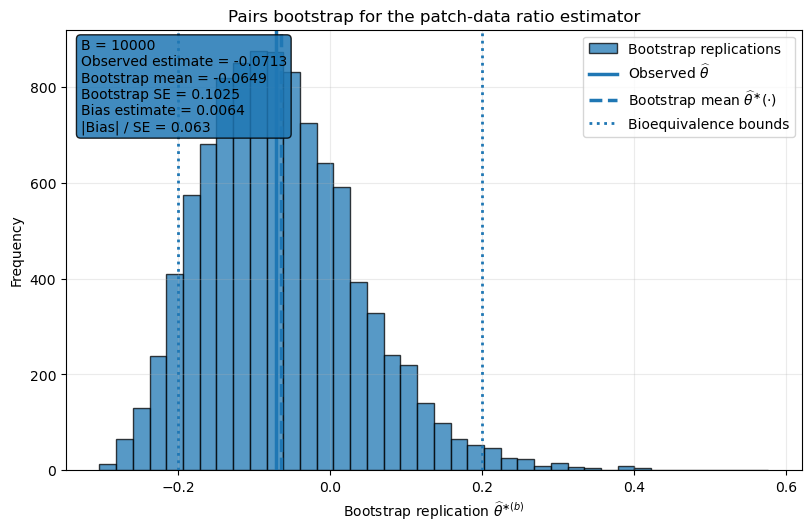

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.2), constrained_layout=True)

ax.hist(theta_star, bins=40, edgecolor="black", alpha=0.75, label="Bootstrap replications")
ax.axvline(theta_hat, linestyle="-", linewidth=2.5, label=r"Observed $\widehat{\theta}$")
ax.axvline(theta_star_mean, linestyle="--", linewidth=2.5, label=r"Bootstrap mean $\widehat{\theta}^{\ast}(\cdot)$")
ax.axvline(-0.20, linestyle=":", linewidth=2.0, label="Bioequivalence bounds")
ax.axvline(0.20, linestyle=":", linewidth=2.0)

text = (
    f"B = {B}\n"
    f"Observed estimate = {theta_hat:.4f}\n"
    f"Bootstrap mean = {theta_star_mean:.4f}\n"
    f"Bootstrap SE = {se_boot:.4f}\n"
    f"Bias estimate = {bias_boot:.4f}\n"
    f"|Bias| / SE = {bias_to_se_ratio:.3f}"
)
ax.text(0.02, 0.98, text, transform=ax.transAxes, va="top", fontsize=10,
        bbox={"boxstyle": "round", "alpha": 0.85})

ax.set_xlabel(r"Bootstrap replication $\widehat{\theta}^{\ast (b)}$")
ax.set_ylabel("Frequency")
ax.set_title("Pairs bootstrap for the patch-data ratio estimator")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)

output_dir = Path("bias_figures")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "patch_bias_histogram.pdf", bbox_inches="tight")
fig.savefig(output_dir / "patch_bias_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

## Optional: Monte Carlo stability check

The number of bootstrap replications controls Monte Carlo error.  It does not reduce the sampling uncertainty in the original data.

In [8]:
def summarize_for_B(B, seed=123):
    theta_star_B = pairs_bootstrap_ratio(Y, Z, B=B, seed=seed)
    theta_star_mean_B = theta_star_B.mean()
    se_B = theta_star_B.std(ddof=1)
    bias_B = theta_star_mean_B - theta_hat
    return {
        "B": B,
        "Bootstrap mean": theta_star_mean_B,
        "Bootstrap SE": se_B,
        "Bias estimate": bias_B,
        "|Bias| / SE": abs(bias_B) / se_B,
        "MC bound": 2 * se_B / np.sqrt(B),
    }

stability = pd.DataFrame([summarize_for_B(B, seed=123) for B in [400, 1000, 2000, 5000, 10000, 20000]])
stability

,B,Bootstrap mean,Bootstrap SE,Bias estimate,|Bias| / SE,MC bound
0,400,-0.060103,0.103335,0.011203,0.108412,0.010333
1,1000,-0.063000,0.100392,0.008306,0.082734,0.006349
2,2000,-0.065501,0.098855,0.005805,0.058718,0.004421
3,5000,-0.064666,0.101594,0.006640,0.065355,0.002874
4,10000,-0.064897,0.102488,0.006409,0.062536,0.002050
5,20000,-0.064361,0.102754,0.006946,0.067594,0.001453


## Interpretation

In this example the bootstrap standard error is about \(0.10\), while the estimated bias is about \(0.006\).  Thus the estimated bias is small on the scale of the estimator's random variation.

This does not prove that the true bias is exactly zero.  It says that bias is not the dominant source of uncertainty in this example.